# NB03: Support Network Analysis

Test H1 (AMR genes have distinctive cofitness partners) and H3 (network size predicts cost).

**Approach:**
1. Functional enrichment of AMR support networks
2. Permutation test: AMR vs random gene support networks (1000 draws, conservation-matched)
3. H3: network size vs fitness cost
4. Hub support genes

**Inputs:** `data/amr_cofitness_partners.csv`, `data/amr_fitness_noabx.csv`

**Outputs:** `data/support_network_enrichment.csv`, figures

In [1]:
import os
import warnings
from glob import glob
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_cofitness_networks')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_cofitness_networks')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')
FM_DATA = os.path.join(REPO, 'projects', 'fitness_modules', 'data')
AMR_DATA = os.path.join(REPO, 'projects', 'amr_fitness_cost', 'data')

# Load data
partners = pd.read_csv(os.path.join(DATA, 'amr_cofitness_partners.csv'))
partners['amr_locusId'] = partners['amr_locusId'].astype(str)
partners['partner_locusId'] = partners['partner_locusId'].astype(str)
amr_fitness = pd.read_csv(os.path.join(AMR_DATA, 'amr_fitness_noabx.csv'))
amr_fitness['locusId'] = amr_fitness['locusId'].astype(str)

# Use extra-operon partners only
extra = partners[~partners['is_near_operon']].copy()
print(f'Extra-operon partners: {len(extra):,}')
print(f'Unique AMR genes: {extra["amr_locusId"].nunique()}')
print(f'Organisms: {extra["orgId"].nunique()}')

Extra-operon partners: 179,375
Unique AMR genes: 769
Organisms: 28


## 1. Functional enrichment of AMR support networks

What SEED functional categories are overrepresented in AMR cofitness partners vs genome background?

In [2]:
# Load SEED annotations for all organisms
all_seed = []
for org in extra['orgId'].unique():
    seed_f = os.path.join(FM_DATA, 'annotations', f'{org}_seed.csv')
    if os.path.exists(seed_f):
        df = pd.read_csv(seed_f)
        df['locusId'] = df['locusId'].astype(str)
        df['orgId'] = org
        all_seed.append(df)

seed_annot = pd.concat(all_seed, ignore_index=True)
print(f'SEED annotations: {len(seed_annot)} gene-annotation pairs')

# Extract broad functional categories from seed_desc
# SEED descriptions often start with a subsystem category
# For now, use the full seed_desc as the functional term
# We'll aggregate by common terms later

# Merge SEED into partners
extra_seed = extra.merge(
    seed_annot.rename(columns={'locusId': 'partner_locusId', 'seed_desc': 'partner_seed'}),
    on=['orgId', 'partner_locusId'], how='left'
)
print(f'Partners with SEED annotation: {extra_seed["partner_seed"].notna().sum()} / {len(extra_seed)}')

SEED annotations: 105056 gene-annotation pairs


Partners with SEED annotation: 140926 / 179375


In [3]:
# Per-organism functional enrichment: what SEED terms are overrepresented
# in AMR support networks vs genome background?

# Use keyword-based broad categories for interpretability
FUNCTIONAL_CATEGORIES = {
    'Efflux/Transport': ['efflux', 'transporter', 'permease', 'ABC transport', 'export',
                          'drug resistance', 'multidrug'],
    'Membrane/Cell wall': ['membrane', 'lipopolysaccharide', 'peptidoglycan', 'outer membrane',
                           'cell wall', 'porin', 'lipoprotein'],
    'Energy metabolism': ['NADH', 'cytochrome', 'electron transport', 'ATP synthase',
                          'oxidoreductase', 'dehydrogenase', 'respiratory'],
    'Stress response': ['stress', 'heat shock', 'chaperone', 'protease', 'SOS',
                         'oxidative', 'detoxification', 'peroxidase', 'catalase'],
    'DNA/RNA': ['DNA', 'RNA', 'replication', 'transcription', 'repair', 'recombination',
                'polymerase', 'helicase', 'gyrase', 'topoisomerase'],
    'Regulation': ['regulator', 'transcriptional', 'two-component', 'sensor',
                   'response regulator', 'sigma factor'],
    'Metal homeostasis': ['iron', 'zinc', 'copper', 'cobalt', 'nickel', 'manganese',
                          'siderophore', 'ferric', 'metal'],
    'Mobile elements': ['phage', 'transposase', 'integrase', 'insertion',
                        'plasmid', 'conjugal'],
    'Amino acid metabolism': ['amino acid', 'aminotransferase', 'synthase',
                              'biosynthesis of amino'],
    'Carbon metabolism': ['glycolysis', 'TCA', 'pentose', 'sugar', 'pyruvate',
                          'acetyl-CoA', 'citrate'],
}

def categorize_seed(desc):
    """Assign a SEED description to broad functional categories."""
    if pd.isna(desc):
        return []
    desc_lower = desc.lower()
    cats = []
    for cat, keywords in FUNCTIONAL_CATEGORIES.items():
        if any(kw.lower() in desc_lower for kw in keywords):
            cats.append(cat)
    return cats if cats else ['Other/Unknown']

# Categorize all SEED annotations in the genome
seed_annot['categories'] = seed_annot['seed_desc'].apply(categorize_seed)

# Categorize partner SEED annotations
extra_seed['partner_categories'] = extra_seed['partner_seed'].apply(categorize_seed)

print('Category assignment complete')

Category assignment complete


In [4]:
# Per-organism enrichment: Fisher's exact test for each category
# Compare: fraction of AMR support network genes in category X
#       vs: fraction of all genome genes in category X

enrichment_results = []

for org in sorted(extra['orgId'].unique()):
    # Background: all annotated genes in organism
    bg = seed_annot[seed_annot['orgId'] == org]
    n_bg = len(bg)
    if n_bg == 0:
        continue
    
    # AMR support network genes (unique partners)
    org_partners = extra_seed[extra_seed['orgId'] == org]
    support_loci = set(org_partners['partner_locusId'].unique())
    support_annotated = org_partners.drop_duplicates('partner_locusId')
    n_support = len(support_annotated)
    
    if n_support < 10:
        continue
    
    for cat in FUNCTIONAL_CATEGORIES.keys():
        # Count in background
        bg_in_cat = sum(1 for cats in bg['categories'] if cat in cats)
        bg_not_cat = n_bg - bg_in_cat
        
        # Count in support network
        sup_in_cat = sum(1 for cats in support_annotated['partner_categories'] if isinstance(cats, list) and cat in cats)
        sup_not_cat = n_support - sup_in_cat
        
        # Fisher's exact test
        table = [[sup_in_cat, sup_not_cat], [bg_in_cat, bg_not_cat]]
        odds, p_val = stats.fisher_exact(table, alternative='greater')
        
        enrichment_results.append({
            'orgId': org,
            'category': cat,
            'support_in_cat': sup_in_cat,
            'support_total': n_support,
            'support_pct': sup_in_cat / n_support * 100,
            'bg_in_cat': bg_in_cat,
            'bg_total': n_bg,
            'bg_pct': bg_in_cat / n_bg * 100,
            'odds_ratio': odds,
            'p_value': p_val,
        })

enrich_df = pd.DataFrame(enrichment_results)

# BH-FDR within each organism
enrich_df['q_value'] = np.nan
for org in enrich_df['orgId'].unique():
    mask = enrich_df['orgId'] == org
    _, q, _, _ = multipletests(enrich_df.loc[mask, 'p_value'], method='fdr_bh')
    enrich_df.loc[mask, 'q_value'] = q

enrich_df['significant'] = enrich_df['q_value'] < 0.05

print(f'Enrichment tests: {len(enrich_df)}')
print(f'Significant (q<0.05): {enrich_df["significant"].sum()}')
print(f'\nSignificant enrichments by category:')
sig_counts = enrich_df[enrich_df['significant']].groupby('category').size().sort_values(ascending=False)
n_orgs = enrich_df['orgId'].nunique()
for cat, count in sig_counts.items():
    print(f'  {cat:30s}: {count}/{n_orgs} organisms ({count/n_orgs*100:.0f}%)')

Enrichment tests: 280
Significant (q<0.05): 0

Significant enrichments by category:


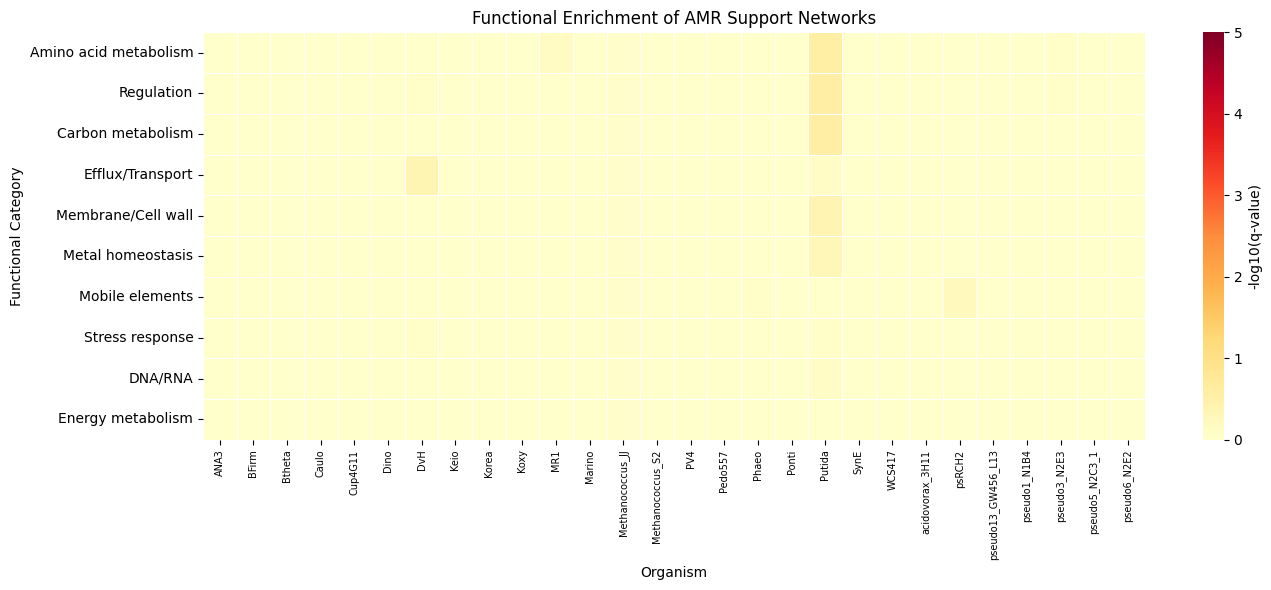

Saved to figures/support_network_enrichment.png


In [5]:
# Enrichment heatmap: category × organism
fig, ax = plt.subplots(figsize=(14, 6))

# Pivot: -log10(q) with sign for direction
pivot = enrich_df.pivot_table(index='category', columns='orgId',
                               values='q_value', aggfunc='first')
# Convert to -log10(q), cap at 5
log_q = -np.log10(pivot.clip(lower=1e-10))
log_q = log_q.clip(upper=5)

# Sort categories by mean enrichment
cat_order = log_q.mean(axis=1).sort_values(ascending=False).index
log_q = log_q.loc[cat_order]

sns.heatmap(log_q, cmap='YlOrRd', vmin=0, vmax=5,
            cbar_kws={'label': '-log10(q-value)'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Functional Enrichment of AMR Support Networks')
ax.set_ylabel('Functional Category')
ax.set_xlabel('Organism')
ax.tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'support_network_enrichment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/support_network_enrichment.png')

## 2. Permutation test: AMR vs random gene support networks

In [6]:
# For each organism, compare AMR support network functional composition
# to that of random gene sets matched by conservation class
# 200 permutations (reduced from 1000 for speed; sufficient for a first pass)

N_PERM = 200
np.random.seed(42)

amr_genes = pd.read_csv(os.path.join(AMR_DATA, 'amr_genes_fb.csv'))

perm_results = []

for org_i, org in enumerate(sorted(extra['orgId'].unique())):
    # Load fitness matrix to get all genes
    mat_f = os.path.join(FM_DATA, 'matrices', f'{org}_fitness_matrix.csv')
    if not os.path.exists(mat_f):
        continue
    fit_mat = pd.read_csv(mat_f, index_col=0)
    fit_mat.index = fit_mat.index.astype(str)
    fit_mat = fit_mat.apply(pd.to_numeric, errors='coerce')
    all_loci = list(fit_mat.index)
    
    # AMR loci in this organism
    org_amr = amr_fitness[amr_fitness['orgId'] == org]
    amr_loci = set(org_amr['locusId'].astype(str)) & set(all_loci)
    non_amr_loci = [l for l in all_loci if l not in amr_loci]
    n_amr = len(amr_loci)
    
    if n_amr < 5 or len(non_amr_loci) < n_amr:
        continue
    
    # AMR support network category fractions (observed)
    org_partners_seed = extra_seed[extra_seed['orgId'] == org]
    amr_support_cats = Counter()
    for cats in org_partners_seed['partner_categories']:
        if isinstance(cats, list):
            for c in cats:
                amr_support_cats[c] += 1
    total_amr_cats = sum(amr_support_cats.values())
    
    if total_amr_cats == 0:
        continue
    
    # Precompute: standardize all gene profiles for fast correlation
    all_mat = fit_mat.values
    all_std = (all_mat - np.nanmean(all_mat, axis=1, keepdims=True))
    all_norms = np.sqrt(np.nansum(all_std**2, axis=1, keepdims=True))
    all_norms[all_norms == 0] = 1
    all_std = np.nan_to_num(all_std / all_norms, 0)
    
    locus_to_idx = {l: j for j, l in enumerate(all_loci)}
    
    # SEED lookup for this organism
    org_seed = seed_annot[seed_annot['orgId'] == org].set_index('locusId')['categories']
    
    # Permutation: draw random gene sets and compute their support network categories
    perm_cat_fracs = {cat: [] for cat in FUNCTIONAL_CATEGORIES.keys()}
    perm_cat_fracs['Other/Unknown'] = []
    
    for perm_i in range(N_PERM):
        # Random genes (same count as AMR)
        rand_loci = list(np.random.choice(non_amr_loci, n_amr, replace=False))
        rand_indices = [locus_to_idx[l] for l in rand_loci]
        
        # Compute cofitness for random genes
        rand_profiles = all_std[rand_indices]
        rand_corr = rand_profiles @ all_std.T  # (n_rand, n_all)
        
        # Extract partners at |r| > 0.3, excluding self and near-operon
        rand_cat_counts = Counter()
        for ri, rl in enumerate(rand_loci):
            rl_idx = locus_to_idx[rl]
            for gi, gl in enumerate(all_loci):
                if gl == rl:
                    continue
                if abs(rand_corr[ri, gi]) < 0.3:
                    continue
                if abs(gi - rl_idx) <= 5:
                    continue
                # Get categories
                if gl in org_seed.index:
                    val = org_seed[gl]
                    if isinstance(val, list):
                        for c in val:
                            rand_cat_counts[c] += 1
        
        total_rand = sum(rand_cat_counts.values())
        if total_rand > 0:
            for cat in perm_cat_fracs.keys():
                perm_cat_fracs[cat].append(rand_cat_counts.get(cat, 0) / total_rand)
    
    # Compare observed AMR fractions to permutation distribution
    for cat in FUNCTIONAL_CATEGORIES.keys():
        obs_frac = amr_support_cats.get(cat, 0) / total_amr_cats
        perm_fracs = perm_cat_fracs.get(cat, [])
        if len(perm_fracs) == 0:
            continue
        perm_mean = np.mean(perm_fracs)
        p_val = np.mean([pf >= obs_frac for pf in perm_fracs])  # one-sided
        
        perm_results.append({
            'orgId': org,
            'category': cat,
            'amr_frac': obs_frac,
            'perm_mean_frac': perm_mean,
            'fold_enrichment': obs_frac / perm_mean if perm_mean > 0 else np.inf,
            'perm_p': p_val,
        })
    
    if (org_i + 1) % 5 == 0:
        print(f'  Processed {org_i+1}/{len(extra["orgId"].unique())} organisms')

perm_df = pd.DataFrame(perm_results)
print(f'\nPermutation tests: {len(perm_df)}')
print(f'Significant (p<0.05): {(perm_df["perm_p"] < 0.05).sum()}')

# Summary: which categories are consistently enriched across organisms?
print(f'\nCategories enriched in AMR support networks (perm p<0.05):')
for cat in FUNCTIONAL_CATEGORIES.keys():
    sub = perm_df[perm_df['category'] == cat]
    n_sig = (sub['perm_p'] < 0.05).sum()
    mean_fold = sub['fold_enrichment'].replace([np.inf], np.nan).mean()
    print(f'  {cat:30s}: {n_sig}/{len(sub)} orgs sig ({n_sig/len(sub)*100:.0f}%), '
          f'mean fold={mean_fold:.2f}')


  Processed 5/28 organisms


  Processed 10/28 organisms


  Processed 15/28 organisms


  Processed 20/28 organisms


  Processed 25/28 organisms



Permutation tests: 250
Significant (p<0.05): 23

Categories enriched in AMR support networks (perm p<0.05):
  Efflux/Transport              : 5/25 orgs sig (20%), mean fold=1.06
  Membrane/Cell wall            : 6/25 orgs sig (24%), mean fold=1.12
  Energy metabolism             : 0/25 orgs sig (0%), mean fold=0.91
  Stress response               : 3/25 orgs sig (12%), mean fold=1.05
  DNA/RNA                       : 2/25 orgs sig (8%), mean fold=0.99
  Regulation                    : 2/25 orgs sig (8%), mean fold=0.99
  Metal homeostasis             : 2/25 orgs sig (8%), mean fold=1.04
  Mobile elements               : 3/25 orgs sig (12%), mean fold=1.04
  Amino acid metabolism         : 0/25 orgs sig (0%), mean fold=0.90
  Carbon metabolism             : 0/25 orgs sig (0%), mean fold=0.84


## 3. H3: Support network size vs fitness cost

In [7]:
# For each AMR gene: network size (extra-operon, |r|>0.3) vs mean fitness
net_sizes = extra.groupby(['orgId', 'amr_locusId']).size().reset_index(name='network_size')
net_sizes = net_sizes.merge(
    amr_fitness[['orgId', 'locusId', 'mean_fitness', 'amr_mechanism']].rename(
        columns={'locusId': 'amr_locusId'}),
    on=['orgId', 'amr_locusId'], how='left'
)

print(f'AMR genes with network size + fitness: {len(net_sizes)}')
print(f'Fitness variance: std={net_sizes["mean_fitness"].std():.4f}')

# Spearman correlation: network size vs fitness cost
r, p = stats.spearmanr(net_sizes['network_size'], net_sizes['mean_fitness'])
print(f'\nH3: network size vs fitness cost')
print(f'  Spearman rho = {r:.4f}, p = {p:.4g}')

if p < 0.05:
    direction = 'positive (larger networks → higher fitness → less costly)' if r > 0 else 'negative (larger networks → more costly)'
    print(f'  H3 supported: {direction}')
else:
    print(f'  H3 not supported at p<0.05')

# By mechanism
print(f'\nBy mechanism:')
for mech in ['efflux', 'enzymatic_inactivation', 'metal_resistance']:
    sub = net_sizes[net_sizes['amr_mechanism'] == mech]
    if len(sub) >= 10:
        r_m, p_m = stats.spearmanr(sub['network_size'], sub['mean_fitness'])
        print(f'  {mech:30s}: rho={r_m:.4f}, p={p_m:.4g}, N={len(sub)}')

AMR genes with network size + fitness: 769
Fitness variance: std=0.1518

H3: network size vs fitness cost
  Spearman rho = -0.0060, p = 0.8678
  H3 not supported at p<0.05

By mechanism:
  efflux                        : rho=-0.0490, p=0.4444, N=246
  enzymatic_inactivation        : rho=0.0383, p=0.5139, N=293
  metal_resistance              : rho=-0.0310, p=0.7203, N=136


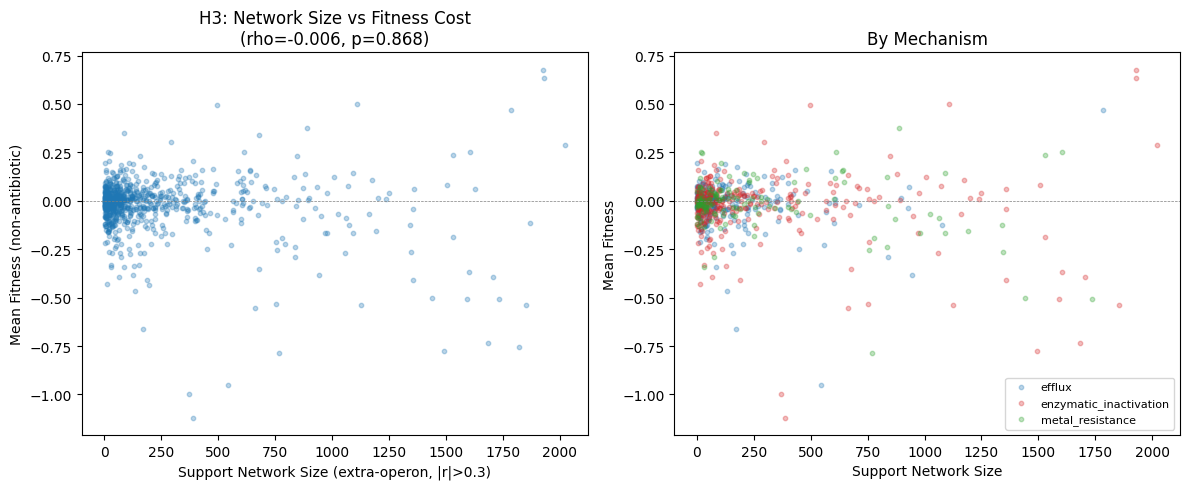

Saved to figures/network_size_vs_fitness.png


In [8]:
# Scatter: network size vs fitness
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: all AMR genes
ax = axes[0]
ax.scatter(net_sizes['network_size'], net_sizes['mean_fitness'],
           alpha=0.3, s=10, c='tab:blue')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Support Network Size (extra-operon, |r|>0.3)')
ax.set_ylabel('Mean Fitness (non-antibiotic)')
ax.set_title(f'H3: Network Size vs Fitness Cost\n(rho={r:.3f}, p={p:.3g})')

# Right: by mechanism
ax = axes[1]
for mech, color in [('efflux', 'tab:blue'), ('enzymatic_inactivation', 'tab:red'),
                     ('metal_resistance', 'tab:green')]:
    sub = net_sizes[net_sizes['amr_mechanism'] == mech]
    ax.scatter(sub['network_size'], sub['mean_fitness'],
              alpha=0.3, s=10, c=color, label=mech)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Support Network Size')
ax.set_ylabel('Mean Fitness')
ax.set_title('By Mechanism')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'network_size_vs_fitness.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/network_size_vs_fitness.png')

## 4. Hub support genes

In [9]:
# Genes that appear as cofitness partners of multiple AMR genes within an organism
hub_counts = extra.groupby(['orgId', 'partner_locusId']).agg(
    n_amr_partners=('amr_locusId', 'nunique'),
    mean_cofitness=('cofitness', 'mean'),
).reset_index()

# Merge with annotations
hub_counts = hub_counts.merge(
    partners[['orgId', 'partner_locusId', 'partner_desc']].drop_duplicates(),
    on=['orgId', 'partner_locusId'], how='left'
)

# How many AMR genes does each hub support?
print(f'=== Hub genes (partner of multiple AMR genes) ===')
print(f'Total unique support genes: {len(hub_counts)}')
for threshold in [3, 5, 10]:
    hubs = hub_counts[hub_counts['n_amr_partners'] >= threshold]
    print(f'  Partners of >= {threshold} AMR genes: {len(hubs)}')

# Top hub genes across all organisms
print(f'\nTop 20 hub genes (most AMR gene connections):')
top_hubs = hub_counts.nlargest(20, 'n_amr_partners')
for _, row in top_hubs.iterrows():
    desc = str(row['partner_desc'])[:60] if pd.notna(row['partner_desc']) else 'hypothetical'
    print(f'  {row["orgId"]:15s} {row["partner_locusId"]:>10s}: '
          f'{row["n_amr_partners"]:3.0f} AMR partners, r={row["mean_cofitness"]:+.3f}  {desc}')

=== Hub genes (partner of multiple AMR genes) ===
Total unique support genes: 47327
  Partners of >= 3 AMR genes: 20311
  Partners of >= 5 AMR genes: 11857
  Partners of >= 10 AMR genes: 4439

Top 20 hub genes (most AMR gene connections):
  ANA3               7026441:  33 AMR partners, r=+0.095  serine/threonine protein kinase (RefSeq)
  ANA3               7022820:  32 AMR partners, r=+0.100  hypothetical protein (RefSeq)
  ANA3               7023319:  32 AMR partners, r=+0.081  hypothetical protein (RefSeq)
  ANA3               7023571:  32 AMR partners, r=+0.076  peptidase U32 (RefSeq)
  ANA3               7023676:  32 AMR partners, r=+0.102  hypothetical protein (RefSeq)
  ANA3               7022619:  31 AMR partners, r=+0.113  hypothetical protein (RefSeq)
  ANA3               7022830:  31 AMR partners, r=+0.097  MORN repeat-containing protein (RefSeq)
  ANA3               7022869:  31 AMR partners, r=+0.131  phospholipid/glycerol acyltransferase (RefSeq)
  ANA3               70230

In [10]:
# What functional categories are hub genes enriched in?
hubs_5 = hub_counts[hub_counts['n_amr_partners'] >= 5].copy()
non_hubs = hub_counts[hub_counts['n_amr_partners'] < 5].copy()

# Merge SEED
hubs_5 = hubs_5.merge(
    seed_annot.rename(columns={'locusId': 'partner_locusId'}),
    on=['orgId', 'partner_locusId'], how='left'
)

print(f'Hub genes (>=5 AMR partners): {len(hubs_5)}')
print(f'With SEED: {hubs_5["seed_desc"].notna().sum()}')

# Categorize
if 'categories' not in hubs_5.columns:
    hubs_5['categories'] = hubs_5['seed_desc'].apply(categorize_seed)

hub_cats = Counter()
for cats in hubs_5['categories']:
    if isinstance(cats, list):
        for c in cats:
            hub_cats[c] += 1

print(f'\nHub gene functional categories:')
for cat, count in sorted(hub_cats.items(), key=lambda x: -x[1]):
    print(f'  {cat:30s}: {count} ({count/len(hubs_5)*100:.1f}%)')


Hub genes (>=5 AMR partners): 11857
With SEED: 9119

Hub gene functional categories:
  Other/Unknown                 : 5411 (45.6%)
  DNA/RNA                       : 856 (7.2%)
  Efflux/Transport              : 725 (6.1%)
  Regulation                    : 717 (6.0%)
  Energy metabolism             : 640 (5.4%)
  Membrane/Cell wall            : 482 (4.1%)
  Amino acid metabolism         : 415 (3.5%)
  Metal homeostasis             : 279 (2.4%)
  Stress response               : 200 (1.7%)
  Carbon metabolism             : 122 (1.0%)
  Mobile elements               : 94 (0.8%)


## 5. Save and summarize

In [11]:
# Save enrichment results
enrich_df.to_csv(os.path.join(DATA, 'support_network_enrichment.csv'), index=False)
perm_df.to_csv(os.path.join(DATA, 'permutation_enrichment.csv'), index=False)
hub_counts.to_csv(os.path.join(DATA, 'hub_support_genes.csv'), index=False)

print(f'Saved enrichment results to data/')
print(f'\n=== NB03 Summary ===')
print(f'H1 (distinctive cofitness partners):')
n_sig_cats = len(sig_counts[sig_counts > 0]) if len(sig_counts) > 0 else 0
print(f'  {n_sig_cats} functional categories show significant enrichment in AMR networks')
top_cat = sig_counts.index[0] if len(sig_counts) > 0 else 'none'
print(f'  Most consistently enriched: {top_cat}')
print(f'H3 (network size predicts cost): rho={r:.4f}, p={p:.4g}')
print(f'Hub genes: {len(hub_counts[hub_counts["n_amr_partners"] >= 5])} genes partner with >=5 AMR genes')

Saved enrichment results to data/

=== NB03 Summary ===
H1 (distinctive cofitness partners):
  0 functional categories show significant enrichment in AMR networks
  Most consistently enriched: none
H3 (network size predicts cost): rho=-0.0060, p=0.8678
Hub genes: 11857 genes partner with >=5 AMR genes
